# Unsupervised Learning Analysis

PCA, t-SNE dimensionality reduction, clustering analysis, and natural separation investigation.

In [ ]:
# Required imports and setupimport numpy as npimport pandas as pdimport matplotlib.pyplot as pltfrom pathlib import Path# Load pre-computed resultsRESULTS_DIR = Path('../docs/output')df_shape = pd.read_csv(RESULTS_DIR / 'ch2_waveform_shape_features.csv')print(f'Loaded {len(df_shape)} events with shape features')print(f'Columns: {list(df_shape.columns)}')

# Unsupervised Learning Analysis

Can we find natural clusters in the CH2 waveform features without using the time-of-flight labels? If neutrons and gammas have different pulse shapes, unsupervised methods should reveal distinct clusters.

In [127]:
# Unsupervised Learning - Dimensionality Reduction and Clustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

print("="*80)
print("UNSUPERVISED LEARNING ANALYSIS")
print("="*80)

# Use same features as BDT (non-saturated events only)
feature_cols_unsup = ['rise_time_ns', 'fall_time_ns', 'fwhm_ns', 'peak_amplitude_v', 
                      'charge_asymmetry', 'tail_to_peak_ratio', 'baseline_std_v', 'total_charge_v_s']

df_unsup = df_shape[feature_cols_unsup + ['delta_t_ns']].dropna()
X_unsup = df_unsup[feature_cols_unsup].values
delta_t_unsup = df_unsup['delta_t_ns'].values

# True labels (for validation only - not used in clustering)
y_true_unsup = (delta_t_unsup > 20.0).astype(int)

print(f"\nDataset (non-saturated CH2 waveforms):")
print(f"  Total events: {len(X_unsup)}")
print(f"  Features: {len(feature_cols_unsup)}")
print(f"  Known neutrons (Δt > 20 ns): {y_true_unsup.sum()} ({100*y_true_unsup.mean():.1f}%)")

# Standardize features
scaler_unsup = StandardScaler()
X_scaled = scaler_unsup.fit_transform(X_unsup)

# 1. PCA - Principal Component Analysis
print("\n--- PCA Analysis ---")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Explained variance ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"  Total: {pca.explained_variance_ratio_.sum():.1%}")

# 2. t-SNE - t-distributed Stochastic Neighbor Embedding
print("\n--- t-SNE Analysis ---")
print("Computing t-SNE embedding (this may take a minute)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
print("t-SNE complete.")

UNSUPERVISED LEARNING ANALYSIS

Dataset (non-saturated CH2 waveforms):
  Total events: 9131
  Features: 8
  Known neutrons (Δt > 20 ns): 2058 (22.5%)

--- PCA Analysis ---
Explained variance ratio:
  PC1: 32.9%
  PC2: 24.6%
  Total: 57.5%

--- t-SNE Analysis ---
Computing t-SNE embedding (this may take a minute)...
t-SNE complete.


✓ Dimensionality reduction plot saved to: /Users/virgolaema/Software/3det/Osc_Data/two_channel_neutron_gamma/unsupervised_dimensionality_reduction.png


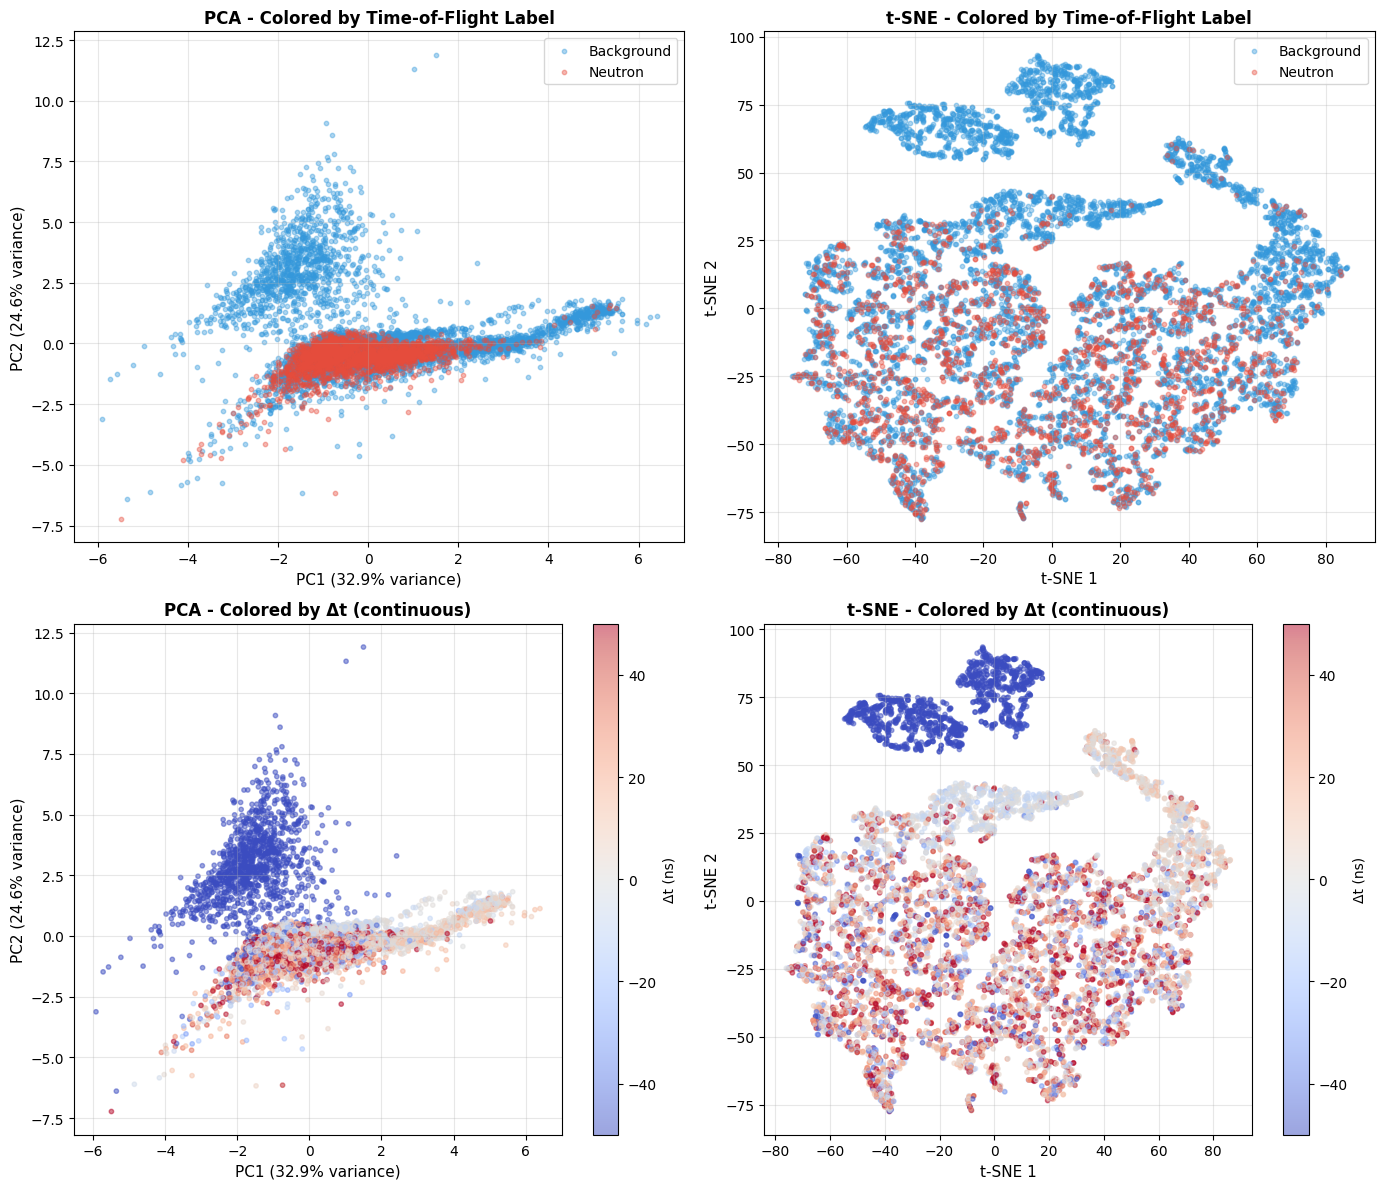


------------------------------------------------------------
INTERPRETATION
------------------------------------------------------------

If neutrons and background have different pulse shapes, you would see:
  - GOOD separation: Red and blue points form distinct clusters
  - POOR separation: Red and blue points are mixed throughout

Look at the plots above to judge the natural clustering structure.



In [128]:
# Visualize dimensionality reduction - colored by TRUE labels (delta_t)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Color maps
colors_true = np.array(['#3498db', '#e74c3c'])  # blue=background, red=neutron

# Top-left: PCA colored by true labels
ax1 = axes[0, 0]
for label, color, name in [(0, '#3498db', 'Background'), (1, '#e74c3c', 'Neutron')]:
    mask = y_true_unsup == label
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, alpha=0.4, s=10, label=name)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
ax1.set_title('PCA - Colored by Time-of-Flight Label', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Top-right: t-SNE colored by true labels
ax2 = axes[0, 1]
for label, color, name in [(0, '#3498db', 'Background'), (1, '#e74c3c', 'Neutron')]:
    mask = y_true_unsup == label
    ax2.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, alpha=0.4, s=10, label=name)
ax2.set_xlabel('t-SNE 1', fontsize=11)
ax2.set_ylabel('t-SNE 2', fontsize=11)
ax2.set_title('t-SNE - Colored by Time-of-Flight Label', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Bottom-left: PCA colored by delta_t (continuous)
ax3 = axes[1, 0]
sc3 = ax3.scatter(X_pca[:, 0], X_pca[:, 1], c=delta_t_unsup, cmap='coolwarm', 
                  alpha=0.5, s=10, vmin=-50, vmax=50)
plt.colorbar(sc3, ax=ax3, label='Δt (ns)')
ax3.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=11)
ax3.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=11)
ax3.set_title('PCA - Colored by Δt (continuous)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Bottom-right: t-SNE colored by delta_t (continuous)
ax4 = axes[1, 1]
sc4 = ax4.scatter(X_tsne[:, 0], X_tsne[:, 1], c=delta_t_unsup, cmap='coolwarm', 
                  alpha=0.5, s=10, vmin=-50, vmax=50)
plt.colorbar(sc4, ax=ax4, label='Δt (ns)')
ax4.set_xlabel('t-SNE 1', fontsize=11)
ax4.set_ylabel('t-SNE 2', fontsize=11)
ax4.set_title('t-SNE - Colored by Δt (continuous)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
dimred_path = RESULTS_DIR / 'unsupervised_dimensionality_reduction.png'
plt.savefig(dimred_path, dpi=150, bbox_inches='tight')
print(f"✓ Dimensionality reduction plot saved to: {dimred_path}")
plt.show()

# Interpretation
print("\n" + "-"*60)
print("INTERPRETATION")
print("-"*60)
print("""
If neutrons and background have different pulse shapes, you would see:
  - GOOD separation: Red and blue points form distinct clusters
  - POOR separation: Red and blue points are mixed throughout

Look at the plots above to judge the natural clustering structure.
""")

In [129]:
# Clustering Analysis - K-Means and Gaussian Mixture Model
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

print("="*80)
print("CLUSTERING ANALYSIS")
print("="*80)

# Try different numbers of clusters
n_clusters_range = [2, 3, 4, 5]

# K-Means clustering
print("\n--- K-Means Clustering ---")
kmeans_results = []
for n_clust in n_clusters_range:
    kmeans = KMeans(n_clusters=n_clust, random_state=42, n_init=10)
    labels_km = kmeans.fit_predict(X_scaled)
    
    # Metrics
    silhouette = silhouette_score(X_scaled, labels_km)
    ari = adjusted_rand_score(y_true_unsup, labels_km)
    nmi = normalized_mutual_info_score(y_true_unsup, labels_km)
    
    kmeans_results.append({
        'n_clusters': n_clust,
        'silhouette': silhouette,
        'ARI': ari,
        'NMI': nmi,
        'labels': labels_km
    })
    print(f"  k={n_clust}: Silhouette={silhouette:.3f}, ARI={ari:.3f}, NMI={nmi:.3f}")

# Gaussian Mixture Model
print("\n--- Gaussian Mixture Model ---")
gmm_results = []
for n_clust in n_clusters_range:
    gmm = GaussianMixture(n_components=n_clust, random_state=42, n_init=5)
    labels_gmm = gmm.fit_predict(X_scaled)
    
    silhouette = silhouette_score(X_scaled, labels_gmm)
    ari = adjusted_rand_score(y_true_unsup, labels_gmm)
    nmi = normalized_mutual_info_score(y_true_unsup, labels_gmm)
    
    gmm_results.append({
        'n_clusters': n_clust,
        'silhouette': silhouette,
        'ARI': ari,
        'NMI': nmi,
        'labels': labels_gmm,
        'bic': gmm.bic(X_scaled)
    })
    print(f"  k={n_clust}: Silhouette={silhouette:.3f}, ARI={ari:.3f}, NMI={nmi:.3f}, BIC={gmm.bic(X_scaled):.0f}")

print("""
Metrics explained:
  - Silhouette: Cluster quality (-1 to 1, higher = better defined clusters)
  - ARI: Agreement with true labels (-1 to 1, higher = clusters match n/γ)
  - NMI: Mutual information with true labels (0 to 1, higher = better match)
  - BIC: Model selection criterion (lower = better fit, penalizes complexity)
""")

CLUSTERING ANALYSIS

--- K-Means Clustering ---
  k=2: Silhouette=0.460, ARI=-0.094, NMI=0.071
  k=3: Silhouette=0.374, ARI=-0.087, NMI=0.066
  k=4: Silhouette=0.379, ARI=-0.087, NMI=0.066
  k=5: Silhouette=0.283, ARI=-0.029, NMI=0.058

--- Gaussian Mixture Model ---
  k=2: Silhouette=0.399, ARI=-0.079, NMI=0.039, BIC=22249
  k=3: Silhouette=0.159, ARI=0.004, NMI=0.056, BIC=11009
  k=4: Silhouette=0.260, ARI=-0.033, NMI=0.053, BIC=-11246
  k=5: Silhouette=0.198, ARI=-0.025, NMI=0.057, BIC=-16257

Metrics explained:
  - Silhouette: Cluster quality (-1 to 1, higher = better defined clusters)
  - ARI: Agreement with true labels (-1 to 1, higher = clusters match n/γ)
  - NMI: Mutual information with true labels (0 to 1, higher = better match)
  - BIC: Model selection criterion (lower = better fit, penalizes complexity)



✓ Clustering comparison saved to: /Users/virgolaema/Software/3det/Osc_Data/two_channel_neutron_gamma/unsupervised_clustering_comparison.png


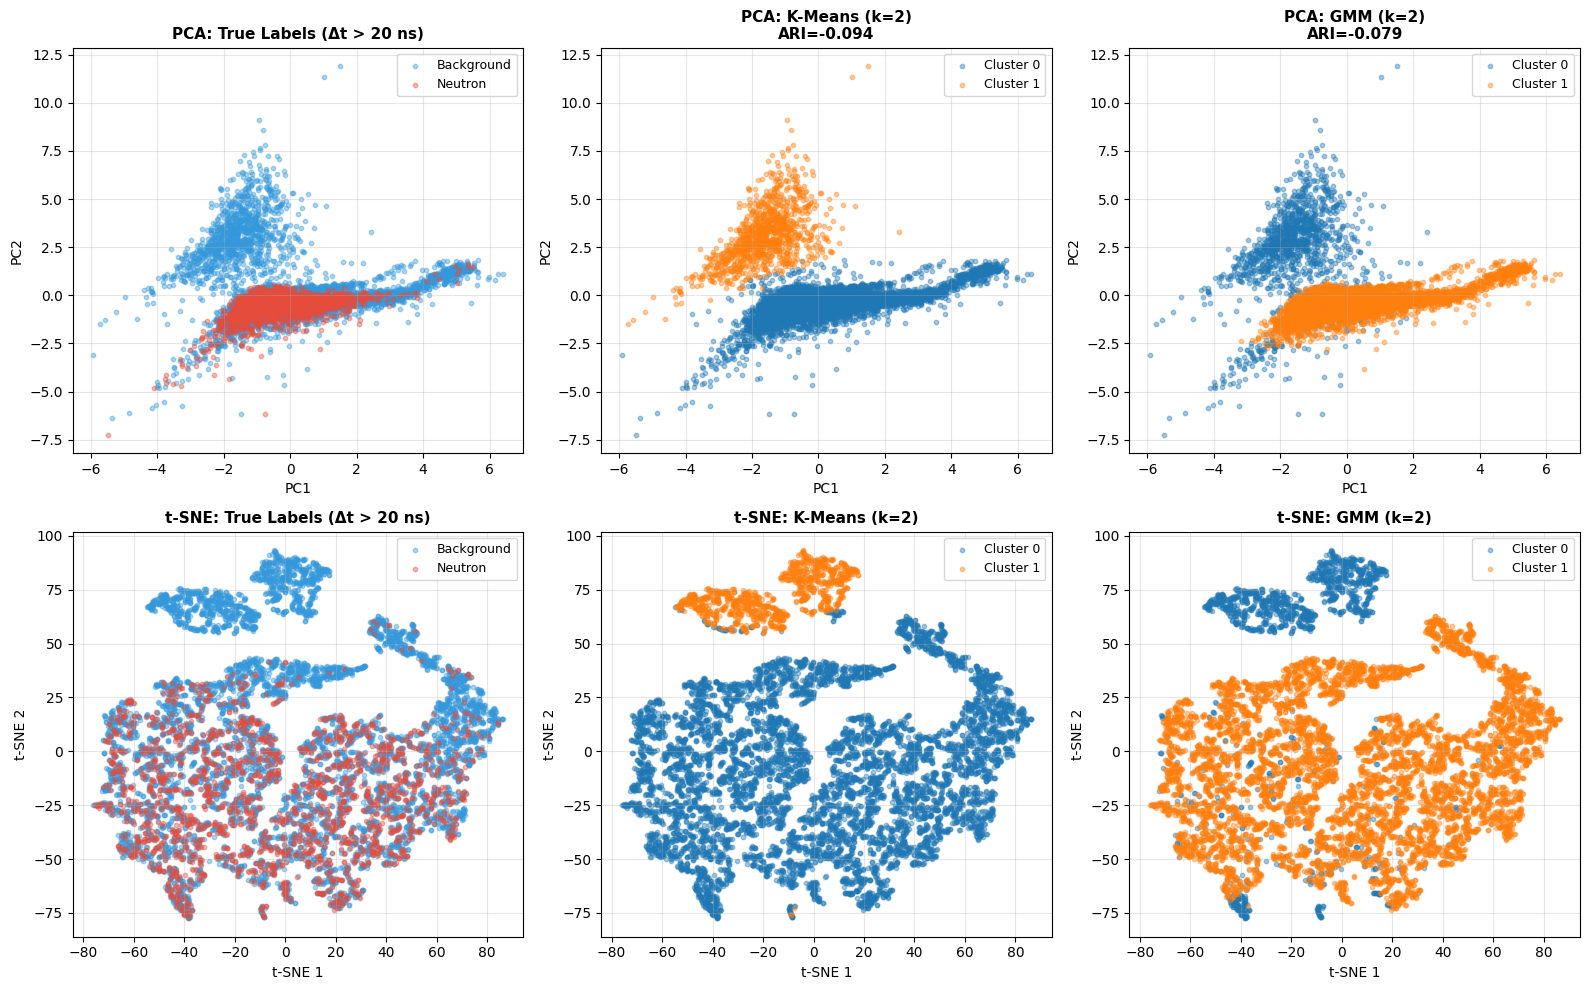

In [130]:
# Visualize clustering results (k=2, compared with true labels)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Get k=2 results
labels_km2 = kmeans_results[0]['labels']
labels_gmm2 = gmm_results[0]['labels']

# Row 1: PCA space
# True labels
ax = axes[0, 0]
for label, color, name in [(0, '#3498db', 'Background'), (1, '#e74c3c', 'Neutron')]:
    mask = y_true_unsup == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, alpha=0.4, s=10, label=name)
ax.set_xlabel('PC1', fontsize=10)
ax.set_ylabel('PC2', fontsize=10)
ax.set_title('PCA: True Labels (Δt > 20 ns)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# K-Means k=2
ax = axes[0, 1]
for label in [0, 1]:
    mask = labels_km2 == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=10, label=f'Cluster {label}')
ax.set_xlabel('PC1', fontsize=10)
ax.set_ylabel('PC2', fontsize=10)
ax.set_title(f'PCA: K-Means (k=2)\nARI={kmeans_results[0]["ARI"]:.3f}', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# GMM k=2
ax = axes[0, 2]
for label in [0, 1]:
    mask = labels_gmm2 == label
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], alpha=0.4, s=10, label=f'Cluster {label}')
ax.set_xlabel('PC1', fontsize=10)
ax.set_ylabel('PC2', fontsize=10)
ax.set_title(f'PCA: GMM (k=2)\nARI={gmm_results[0]["ARI"]:.3f}', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Row 2: t-SNE space
# True labels
ax = axes[1, 0]
for label, color, name in [(0, '#3498db', 'Background'), (1, '#e74c3c', 'Neutron')]:
    mask = y_true_unsup == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=color, alpha=0.4, s=10, label=name)
ax.set_xlabel('t-SNE 1', fontsize=10)
ax.set_ylabel('t-SNE 2', fontsize=10)
ax.set_title('t-SNE: True Labels (Δt > 20 ns)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# K-Means k=2 in t-SNE
ax = axes[1, 1]
for label in [0, 1]:
    mask = labels_km2 == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], alpha=0.4, s=10, label=f'Cluster {label}')
ax.set_xlabel('t-SNE 1', fontsize=10)
ax.set_ylabel('t-SNE 2', fontsize=10)
ax.set_title(f't-SNE: K-Means (k=2)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# GMM k=2 in t-SNE
ax = axes[1, 2]
for label in [0, 1]:
    mask = labels_gmm2 == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], alpha=0.4, s=10, label=f'Cluster {label}')
ax.set_xlabel('t-SNE 1', fontsize=10)
ax.set_ylabel('t-SNE 2', fontsize=10)
ax.set_title(f't-SNE: GMM (k=2)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
clust_path = RESULTS_DIR / 'unsupervised_clustering_comparison.png'
plt.savefig(clust_path, dpi=150, bbox_inches='tight')
print(f"✓ Clustering comparison saved to: {clust_path}")
plt.show()

In [131]:
# Analyze cluster composition - what fraction of each cluster is neutrons?
print("="*80)
print("CLUSTER COMPOSITION ANALYSIS")
print("="*80)

print("\n--- K-Means (k=2) Cluster Composition ---")
for cluster_id in [0, 1]:
    mask = labels_km2 == cluster_id
    n_total = mask.sum()
    n_neutrons = y_true_unsup[mask].sum()
    n_background = n_total - n_neutrons
    purity = n_neutrons / n_total if n_total > 0 else 0
    
    print(f"\nCluster {cluster_id}:")
    print(f"  Total events: {n_total}")
    print(f"  Neutrons: {n_neutrons} ({100*purity:.1f}%)")
    print(f"  Background: {n_background} ({100*(1-purity):.1f}%)")

print("\n--- GMM (k=2) Cluster Composition ---")
for cluster_id in [0, 1]:
    mask = labels_gmm2 == cluster_id
    n_total = mask.sum()
    n_neutrons = y_true_unsup[mask].sum()
    n_background = n_total - n_neutrons
    purity = n_neutrons / n_total if n_total > 0 else 0
    
    print(f"\nCluster {cluster_id}:")
    print(f"  Total events: {n_total}")
    print(f"  Neutrons: {n_neutrons} ({100*purity:.1f}%)")
    print(f"  Background: {n_background} ({100*(1-purity):.1f}%)")

# Summary interpretation
print("\n" + "="*80)
print("UNSUPERVISED LEARNING SUMMARY")
print("="*80)

best_ari = max(kmeans_results[0]['ARI'], gmm_results[0]['ARI'])

print(f"""
KEY FINDINGS:
-------------
• Best ARI score (k=2): {best_ari:.3f}
  - ARI = 0 means random clustering (no correlation with n/γ)
  - ARI = 1 means perfect match with true labels
  
INTERPRETATION:
---------------""")

if best_ari < 0.05:
    print("""
• Clusters do NOT align with neutron/gamma separation
• Pulse shape features do not naturally separate neutrons from background
• The data forms clusters based on OTHER properties (e.g., amplitude ranges)
• CONFIRMS: Time-of-flight is essential for neutron identification
""")
elif best_ari < 0.2:
    print("""
• Clusters show WEAK correlation with neutron/gamma labels
• Some structure exists but not enough for reliable separation
• Unsupervised methods cannot replace time-of-flight
""")
else:
    print("""
• Clusters show MEANINGFUL correlation with neutron/gamma labels
• Pulse shape features contain enough information for partial separation
• Could potentially complement time-of-flight analysis
""")

print("""
WHAT THE CLUSTERS LIKELY REPRESENT:
-----------------------------------
If clusters don't match n/γ labels, they may instead separate:
  • High vs low amplitude events
  • Clean vs noisy waveforms  
  • Different PMT gain regions
  • Electronics effects
""")

CLUSTER COMPOSITION ANALYSIS

--- K-Means (k=2) Cluster Composition ---

Cluster 0:
  Total events: 8077
  Neutrons: 2058 (25.5%)
  Background: 6019 (74.5%)

Cluster 1:
  Total events: 1054
  Neutrons: 0 (0.0%)
  Background: 1054 (100.0%)

--- GMM (k=2) Cluster Composition ---

Cluster 0:
  Total events: 1513
  Neutrons: 92 (6.1%)
  Background: 1421 (93.9%)

Cluster 1:
  Total events: 7618
  Neutrons: 1966 (25.8%)
  Background: 5652 (74.2%)

UNSUPERVISED LEARNING SUMMARY

KEY FINDINGS:
-------------
• Best ARI score (k=2): -0.079
  - ARI = 0 means random clustering (no correlation with n/γ)
  - ARI = 1 means perfect match with true labels

INTERPRETATION:
---------------

• Clusters do NOT align with neutron/gamma separation
• Pulse shape features do not naturally separate neutrons from background
• The data forms clusters based on OTHER properties (e.g., amplitude ranges)
• CONFIRMS: Time-of-flight is essential for neutron identification


WHAT THE CLUSTERS LIKELY REPRESENT:
---------